# 0. Setup e verifica ambiente

Verifichiamo che l'ambiente Python sia correttamente configurato e che la GPU sia visibile sia da CuPy sia da Numba.

Link utili:
- [Docs CuPy](https://docs.cupy.dev/en/stable/index.html)
- [Docs Numba](https://numba.pydata.org/numba-doc/dev/cuda/index.html)

### Setup ambiente Python
Creiamo un ambiente virtuale Python e installiamo le librerie necessarie.

Sul terminale, eseguire i seguenti comandi:

```bash
python3 -m venv cuda_lab
source cuda_lab/bin/activate
pip install --upgrade pip setuptools wheel
pip install matplotlib numba
pip install cupy-cuda13x
pip install matplotlib-inline
pip install nvtx
```

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

import cupy as cp
from numba import cuda


# Verifica GPU
# - stampare le informazioni sulla GPU disponibile
# - verificare che CuPy e Numba vedano il device
# 
print("Numba GPUs:", cuda.gpus)
print("CuPy device:", cp.cuda.runtime.getDeviceProperties(0)['name'])


Numba GPUs: <Managed Device 0>
CuPy device: b'NVIDIA GB10'


"nvidia-smi" da terminale dovrebbe mostrare la GPU disponibile.
Possiamo richiamarlo usando il comando "!" in una cella di Jupyter"

In [2]:
!nvidia-smi

Thu Mar  5 10:25:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GB10                    On  |   0000000F:01:00.0  On |                  N/A |
| N/A   45C    P0              8W /  N/A  | Not Supported          |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 1. NumPy: baseline CPU
In questa sezione utilizziamo NumPy per eseguire semplici operazioni vettoriali su CPU.
Lo scopo è di stabilire una baseline prestazionale che useremo come riferimento quando passeremo alla GPU.


In [3]:
N = 10_000_000

# TO-DO:
# Dati dimensione N, creare due vettori a e b con valori random float32
a = np.random.rand(N).astype(float)
b = np.random.rand(N).astype(float)

# TO-DO:
# - misurare il tempo di esecuzione della somma vettoriale a + b usando time.time() con NumPy

start = time.time()
c = a + b
cpu_time = time.time() - start

print(f"CPU time (NumPy): {cpu_time:.4f} s")


CPU time (NumPy): 0.0064 s


# 2. CuPy: operazioni vettoriali su GPU
CuPy fornisce un’interfaccia compatibile con NumPy ma esegue le operazioni sulla GPU.
Il codice è quasi identico a quello NumPy, ma gli array risiedono in memoria GPU.


In [4]:
a_gpu = cp.random.rand(N).astype(cp.float32)
b_gpu = cp.random.rand(N).astype(cp.float32)

# TO-DO:
# - eseguire la somma vettoriale su GPU
# - sincronizzare correttamente l'esecuzione
# - misurare il tempo reale di esecuzione usando time.time() con CuPy

start = time.time()

c_gpu = a_gpu + b_gpu
# Sincronizzazione GPU
cp.cuda.Stream.null.synchronize()  
gpu_time = time.time() - start

print(f"GPU time (CuPy): {gpu_time:.4f} s")


GPU time (CuPy): 0.0458 s


Ora confrontiamo direttamente CPU e GPU variando la dimensione del problema.
Questo esperimento serve a capire quando l’utilizzo della GPU diventa vantaggioso e quando invece l’overhead domina.

Il tempo di trasferimento dei dati tra memoria host e device è un fattore critico in questo confronto.
Il grafico risultante dovra' mostrare tre curve: CPU, GPU senza trasferimento e GPU con trasferimento end-to-end (inclusi i trasferimenti di memoria in upload e download).

Si consiglia di utilizzare dimensioni del problema che variano da 2^8 a 2^14 


Nota bene: La prima esecuzione di un’operazione su GPU può risultare significativamente più lenta rispetto alle esecuzioni successive.
Questo è dovuto ai costi di inizializzazione del runtime CUDA, all’allocazione iniziale della memoria su GPU e ai meccanismi di autotuning delle librerie sottostanti.

Le prestazioni effettive della GPU si osservano solo dopo una o più esecuzioni di warm-up. Si consiglia di eseguire un’operazione di warm-up prima di misurare i tempi di esecuzione.

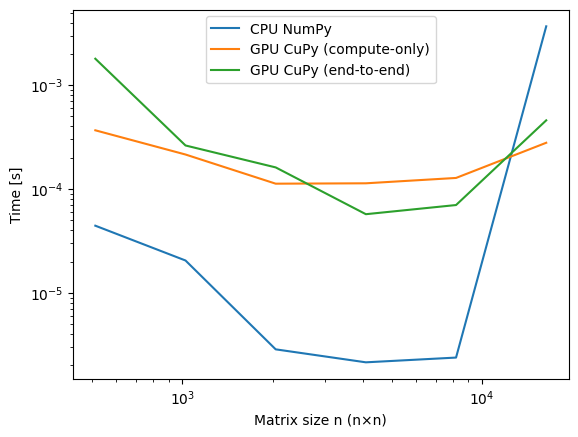

In [5]:
import numpy as np, cupy as cp, time, matplotlib.pyplot as plt

# TO-DO:
# - eseguire la moltiplicazione di matrici di varie dimensioni su CPU e GPU
# - misurare i tempi di esecuzione per CPU, GPU compute-only e GPU end-to-end
# - tracciare il grafico risultante con scala log-log

sizes = [512, 1024, 2048, 4096, 8192, 16384]  # square matrices
cpu_times = []
gpu_times = []
e2e_times = []

for n in sizes:
    A = np.random.rand(n).astype(float)
    B = np.random.rand(n).astype(float)

    # CPU baseline 
    t0 = time.time()
    C = A @ B
    cpu_times.append(time.time() - t0)
    

    # Upload (H->D)
    t0 = time.time()
    # TO-DO: trasferire A e B su GPU e sincronizzare
    A_gpu = cp.asarray(A)
    B_gpu = cp.asarray(B) 
   
    # sincronizzazione GPU
    cp.cuda.Stream.null.synchronize()  
    h2d = time.time() - t0

    # GPU compute-only (kernel)
    # warm-up
    _ = A_gpu @ B_gpu
    cp.cuda.Stream.null.synchronize()

    reps = 5
    t0 = time.time()
    for _ in range(reps):
        C_gpu = A_gpu @ B_gpu
    cp.cuda.Stream.null.synchronize()
    # TO-DO: calcolare il tempo medio per ripetizione
    gpu_times.append(time.time() - t0)

    # Download (D->H)
    t0 = time.time()
    C2 = cp.asnumpy(C_gpu)
    d2h = time.time() - t0

    e2e_times.append(h2d + d2h)

plt.plot(sizes, cpu_times, label="CPU NumPy")
plt.plot(sizes, gpu_times, label="GPU CuPy (compute-only)")
plt.plot(sizes, e2e_times, label="GPU CuPy (end-to-end)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Matrix size n (n×n)")
plt.ylabel("Time [s]")
plt.legend()
plt.show()


# 3. Introduzione ai kernel CUDA con Numba
In questa sezione scriviamo il nostro primo kernel CUDA utilizzando Numba.
A differenza di CuPy, qui il parallelismo è esplicito: ogni thread GPU esegue una parte del lavoro.

Quando si dichiara il numero di thread necessari per un kernel, abbiamo una gerarchia a due livelli

- Dal punto di vista del software, la dimensione del blocco determina quanti thread condividono una determinata area della memoria condivisa.
- Dal punto di vista dell'hardware, la dimensione del blocco deve essere sufficientemente grande da consentire il pieno utilizzo delle unità di esecuzione; le raccomandazioni sono disponibili nella Guida 
[alla programmazione CUDA C.](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)


Dimensioniamo la configurazione di esecuzione come segue:
```python
threadsperblock = ...
dimensione_array = ...
blockspergrid = (dimensione_array + (threadsperblock - 1)) // threadsperblock
```


In [6]:
from numba import cuda

@cuda.jit
def vector_add_numba(a, b, c):
    i = cuda.grid(1)
    if i < c.size:
        c[i] = a[i] + b[i]
        
# TO-DO:
# - allocare memoria device
# - configurare blocks e threads
# - lanciare il kernel
# - copiare il risultato sulla CPU
N = 10_000_000
threads_per_block = 256
blocks_per_grid = (N + (threads_per_block -1)) // threads_per_block
print('blocks: ', blocks_per_grid)
c_gpu_numba = cuda.device_array_like(a)
d_a = cuda.to_device(a)
d_b = cuda.to_device(b)

start = time.time()
# Lanciare il kernel, specificando blocks e threads, passare i vettori device
vector_add_numba[blocks_per_grid, threads_per_block](d_a, d_b, c_gpu_numba)
cuda.synchronize()
numba_time = time.time() - start

print(f"GPU time (Numba): {numba_time:.4f} s")


blocks:  39063
GPU time (Numba): 0.3602 s


# 4. Esperimenti con block e thread
In questa sezione studiamo l’impatto della configurazione di esecuzione (numero di thread per blocco) sulle prestazioni del kernel Numba.

Idea chiave: 
- in CUDA non esiste una singola configurazione “migliore” per ogni GPU e per ogni problema; 
- la configurazione influenza occupazione, overhead e accesso in memoria;

Usiamo lo stesso kernel vector_add_numba definito nella sezione precedente.


In [7]:
# Qualche esperimento con i kernel Numba: 
# cuda.grid(ndim) -> restituisce la posizione assoluta del thread corrente nell'intera griglia di blocchi. 
# ndim dovrebbe corrispondere al numero di dimensioni dichiarate durante l'istanziazione del kernel.
# Se ndim è 1, viene restituito un singolo numero intero. 
# Se ndim è 2 o 3, viene restituita una tupla del numero specificato di numeri interi.

from numba import cuda
def hello_kernel_host():
    print("Hello from CPU!")
    
    
@cuda.jit
def hello_kernel():
    i = cuda.grid(1) # get global thread index
    # Only one thread, the first, will print the message
    if i == 0:
        print("Hello from GPU!")
        
@cuda.jit
def hello_kernel_multiple():
    i = cuda.grid(1) # get global thread index
    # All threads will print their index
    print("Hello from GPU thread", i)


threads = 32
blocks = 1

hello_kernel[blocks, threads]()
print("1-----")
cuda.synchronize()

hello_kernel_multiple[blocks, threads]()
print("2-----")
cuda.synchronize()

hello_kernel_host()
print("3-----")
cuda.synchronize()



1-----
Hello from GPU!
2-----
Hello from CPU!
3-----
Hello from GPU thread 0
Hello from GPU thread 1
Hello from GPU thread 2
Hello from GPU thread 3
Hello from GPU thread 4
Hello from GPU thread 5
Hello from GPU thread 6
Hello from GPU thread 7
Hello from GPU thread 8
Hello from GPU thread 9
Hello from GPU thread 10
Hello from GPU thread 11
Hello from GPU thread 12
Hello from GPU thread 13
Hello from GPU thread 14
Hello from GPU thread 15
Hello from GPU thread 16
Hello from GPU thread 17
Hello from GPU thread 18
Hello from GPU thread 19
Hello from GPU thread 20
Hello from GPU thread 21
Hello from GPU thread 22
Hello from GPU thread 23
Hello from GPU thread 24
Hello from GPU thread 25
Hello from GPU thread 26
Hello from GPU thread 27
Hello from GPU thread 28
Hello from GPU thread 29
Hello from GPU thread 30
Hello from GPU thread 31


/home/e4user/Documents/s362027/lab2/cuda_lab/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/e4user/Documents/s362027/lab2/cuda_lab/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


threads/block=  32  time=0.031313 s
threads/block=  64  time=0.000993 s
threads/block= 128  time=0.000983 s
threads/block= 256  time=0.001145 s
threads/block= 512  time=0.001223 s
threads/block=1024  time=0.001716 s


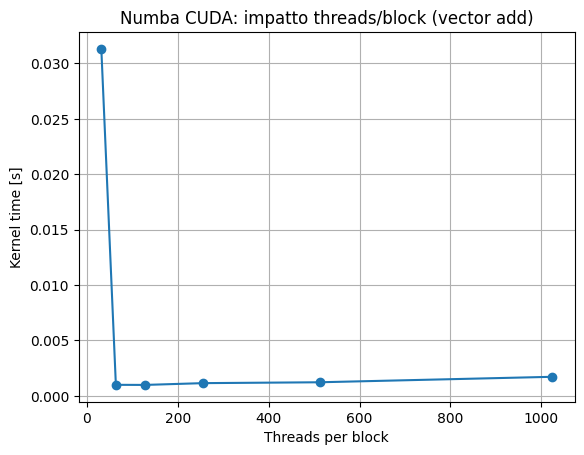

In [8]:
thread_configs = [32, 64, 128, 256, 512, 1024]

# Dati di input
N_exp = 10_000_000_0
a_exp = np.random.rand(N_exp).astype(np.float32)
b_exp = np.random.rand(N_exp).astype(np.float32)

# Copiamo una sola volta i dati su GPU per non confondere il tempo kernel con i trasferimenti.
d_a = cuda.to_device(a_exp)
d_b = cuda.to_device(b_exp)
d_c = cuda.device_array_like(a_exp)

# TO-DO:
# - per ogni configurazione in thread_configs:
#   1) calcolare il numero di blocchi
#   2) lanciare il kernel
#   3) sincronizzare
#   4) salvare il tempo

numba_times = []
for threads_per_block in thread_configs:
    #TO-DO:
    # calcolare e assegnare blocks_per_grid data la dimensione N_exp e threads_per_block
    blocks_per_grid = (N + (threads_per_block -1)) // threads_per_block

    start = time.time()
    vector_add_numba[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()
    numba_times.append(time.time() - start)

for tpb, tt in zip(thread_configs, numba_times):
    print(f"threads/block={tpb:4d}  time={tt:.6f} s")
# Visualizzazione dei risultati
plt.plot(thread_configs, numba_times, marker='o')
plt.xlabel('Threads per block')
plt.ylabel('Kernel time [s]')
plt.title('Numba CUDA: impatto threads/block (vector add)')
plt.grid(True)
plt.show()


Discussione
-	Quale configurazione è risultata più veloce sulla GPU disponibile?
- Le differenze sono marcate o piccole?
- Ci sono configurazioni che peggiorano sensibilmente le prestazioni?

Approfondimento: anche cupy permettte di scrivere kernel personalizzati, ma con una sintassi differente rispetto a numba. Cupy accetta infatti kernel scritti in C++. Ecco un esempio di kernel cupy equivalente a quello numba visto in precedenza.

In [9]:
import cupy as cp

code = r'''
extern "C" __global__
void add(const float* a, const float* b, float* c, int n){
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}
'''

add_kernel = cp.RawKernel(code, "add")

N = 1_000_000
a = cp.random.rand(N).astype(cp.float32)
b = cp.random.rand(N).astype(cp.float32)
c = cp.zeros_like(a)


print("Kernel code:")
print(code)
print("Device of a:", a.device)
print("Device of b:", b.device)
print("Device of c:", c.device)
print("Launching kernel...")

threads = 256
blocks = (N + (threads - 1)) // threads

add_kernel((blocks,), (threads,), (a, b, c, N))
cp.cuda.Stream.null.synchronize()  # Wait for the GPU to finish
print("First 5 elements of a:", a[:5])
print("First 5 elements of b:", b[:5])
print("First 5 elements of c:", c[:5])

Kernel code:

extern "C" __global__
void add(const float* a, const float* b, float* c, int n){
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}

Device of a: <CUDA Device 0>
Device of b: <CUDA Device 0>
Device of c: <CUDA Device 0>
Launching kernel...
First 5 elements of a: [0.9008504  0.21152695 0.876214   0.1578697  0.69404703]
First 5 elements of b: [0.7540096  0.8076133  0.34106565 0.83067536 0.67826104]
First 5 elements of c: [1.65486    1.0191402  1.2172797  0.98854506 1.372308  ]


Confronto prestazioni tra kernel cupy e numba

n=512
CPU NumPy (A@B):          0.0218 s
GPU CuPy  (cuBLAS):       0.0004 s
GPU Numba naive kernel:   2.6041 s
Max error (Numba vs NumPy): 1.068e-04
Max error (CuPy  vs NumPy): 1.144e-04
n=1024
CPU NumPy (A@B):          0.0034 s
GPU CuPy  (cuBLAS):       0.0003 s
GPU Numba naive kernel:   2.6431 s
Max error (Numba vs NumPy): 2.136e-04
Max error (CuPy  vs NumPy): 1.068e-04
n=2048
CPU NumPy (A@B):          0.0235 s
GPU CuPy  (cuBLAS):       0.0022 s
GPU Numba naive kernel:   2.7075 s
Max error (Numba vs NumPy): 3.662e-04
Max error (CuPy  vs NumPy): 6.714e-04


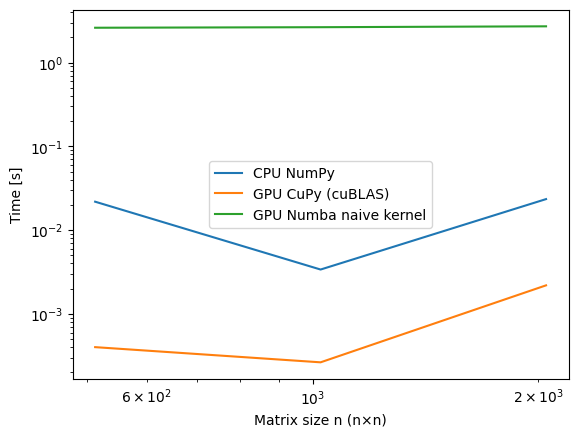

In [10]:
import numpy as np, time
import cupy as cp
from numba import cuda
import matplotlib.pyplot as plt

sizes = [512, 1024, 2048]  # square matrices
cpu_times = []
gpu_cupy_times = []
gpu_numba_times = []


#To-DO:
# definire il kernel Numba per la moltiplicazione di matrici.
# il kernel deve calcolare un elemento C[i,j] della matrice risultato C = A @ B
# Parametri: A, B: matrici di input
# C: matrice risultato
# Funzione:
# definiti gli indici i,j del thread corrente nella griglia 2D, calcolare C[i,j] come somma del prodotto scalare della riga i di A con la colonna j di B.
# -> per k in range della dimensione comune di A e B, sommare A[i,k] * B[k,j]
# Assicurarsi che i e j siano entro i limiti della matrice C.
# Suggerimento: usare cuda.grid(2) per ottenere gli indici globali i,j del thread corrente.


@cuda.jit
def matmul_naive(A, B, C):
    i, j = cuda.grid(2) # TO-DO: ottenere gli indici globali i,j del thread corrente
    if i < C.shape[0] and j < C.shape[1]:
        s = 0.0
        for k in range(A.shape[1]):
            s += A[i, k] * B[k, j]
        C[i, j] = s
            
            
for n in sizes:
    
    np.random.seed(0)

    A = np.random.rand(n, n).astype(np.float32)
    B = np.random.rand(n, n).astype(np.float32)

    # --- CPU baseline (NumPy / BLAS) ---
    t0 = time.time()
    C_np = A @ B
    cpu_time = time.time() - t0
    # --- correctness check will be done later ---
    cpu_times.append(cpu_time)

    # --- GPU baseline (CuPy / cuBLAS) ---
    A_gpu = cp.asarray(A)
    B_gpu = cp.asarray(B)

    # warm-up
    _ = A_gpu @ B_gpu
    cp.cuda.Stream.null.synchronize()

    t0 = time.time()
    C_cupy = A_gpu @ B_gpu
    cp.cuda.Stream.null.synchronize()
    gpu_cupy_time = time.time() - t0
    gpu_cupy_times.append(gpu_cupy_time)

    # --- GPU kernel (Numba naive) ---
    

    d_A = cuda.to_device(A)
    d_B = cuda.to_device(B)
    d_C = cuda.device_array((n, n), dtype=np.float32)

    threads = (16, 16) 
    blocks = (((N + (threads[0] - 1)) // threads[0]), ((N + (threads[1] - 1)) // threads[1])) # TO-DO: calcolare i blocchi necessari per coprire la matrice n x n ->  qui il numero di blocchi e' una tupla di 2 elementi!

    # warm-up (includes JIT compile on first run)
    matmul_naive[blocks, threads](d_A, d_B, d_C)
    cuda.synchronize()
    # TO-DO: misurare il tempo di esecuzione del kernel numba
    # - richiamare il kernel
    # - sincronizzare
    
    t0 = time.time()
    matmul_naive[blocks, threads](d_A, d_B, d_C)
    cuda.synchronize()
    gpu_numba_time = time.time() - t0
    gpu_numba_times.append(gpu_numba_time)

    C_numba = d_C.copy_to_host()

    # --- correctness ---
    max_err_numba = np.max(np.abs(C_np - C_numba))
    max_err_cupy = float(cp.max(cp.abs(C_cupy - cp.asarray(C_np))).get())

    print(f"n={n}")
    print(f"CPU NumPy (A@B):          {cpu_time:.4f} s")
    print(f"GPU CuPy  (cuBLAS):       {gpu_cupy_time:.4f} s")
    print(f"GPU Numba naive kernel:   {gpu_numba_time:.4f} s")
    print(f"Max error (Numba vs NumPy): {max_err_numba:.3e}")
    print(f"Max error (CuPy  vs NumPy): {max_err_cupy:.3e}")

    # Note: first Numba run includes compilation; timings are representative only after warm-up.

#Show plots of the timings
plt.plot(sizes, cpu_times, label="CPU NumPy")
plt.plot(sizes, gpu_cupy_times, label="GPU CuPy (cuBLAS)")
plt.plot(sizes, gpu_numba_times, label="GPU Numba naive kernel")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Matrix size n (n×n)")
plt.ylabel("Time [s]")
plt.legend()


# 5. Conclusioni, Domande aperte e Consegna

Il notebook di lavoro del lab deve essere consegnato nella sezione 'elaborati' sul portale. Questo deve contenere il codice compeleto e i grafici richiesti.
Completare le sezioni contrassegnate con "TO-DO" e rispondere alle seguenti domande (brevemente, indicativamente 3-5 righe per domanda):

- **Quando la GPU offre un vantaggio reale?**
La GPU offre un vantaggio reale quando il problema ha alta intensità computazionale e bassa latenza di memoria. 
Negli esercizi precedenti si nota che per vettori di 10^7 elementi la GPU (CuPy) è competitiva solo se l'overhead di trasferimento H2D/D2H è ammortizzato su molte operazioni. Per operazioni semplici (vector add) su array medio-piccoli, l'overhead domina. 
La GPU brilla su problemi parallelizzabili massiccialmente (matrici grandi, convoluzioni, operazioni batch) dove i thread cooperano intensamente su dati condivisi e l'occupancy GPU è alta.
- **Qual è il costo del trasferimento di memoria nella GPU?**
Dagli esercizi precedenti si osserva che il trasferimento H→D e D→H per vettori di 10^7 elementi float32 (40 MB) impiega millisecondo/decine di millisecondi. Per operazioni veloci (come vector add), questo costo ammortizza il guadagno computazionale.
Per matmul le prestazioni end-to-end mostrano che la transfer latency è significativa: per matrici piccole (<1024²) CPU BLAS è competitivo; per matrici grandi (4096²) il transfer è ignorabile rispetto al tempo di computazione.
- **Perché CuPy è più semplice ma meno controllabile di Numba?**
CuPy fornisce un'API identica a NumPy, richiedendo cambio minimo di codice: A_gpu = cp.asarray(A) poi C = A_gpu @ B_gpu. 
Numba richiede codice CUDA esplicito, ma consente di scegliere autonomamente alcune finezze: shared memory, register blocking, sincronizzazione custom.
- **Perché un kernel GPU può essere più lento della versione NumPy per array piccoli?**
Per array piccoli il kernel GPU soffre di overhead di compilazione, creazione e distribuzione di blocchi/thread nella griglia e tempi di trasferimento H2D/D2H che sono superiori ai tempi di computazione.
- **Qual è la differenza tra parallelismo dei dati e parallelismo dei task nel contesto GPU?**
Nel Data parallelism lo stesso codice esegue su elementi diversi in parallelo (es. vector_add_numba: ogni thread esegue c[i] = a[i] + b[i] su i diversi).
È il modello dominante su GPU moderna, mentre nel Task parallelism task diversi eseguono su dati diversi.
- **Perché la GPU è particolarmente adatta a operazioni elementwise e convoluzioni?**
Entrambe hanno altissima parallelizzabilità con basso overhead di sincronizzazione, sono tipicamente problemi embarassing parallel.
Elementwise (add, mul): ogni elemento è indipendente.
Convoluzioni: ogni output è una combinazione lineare di una piccola finestra di input.
- **Perché l’accesso alla memoria globale è spesso il collo di bottiglia di un kernel CUDA?**
La memoria globale GPU ha latenza alta e limitata larghezza di banda. Nel lab2, il kernel naive matmul legge da memoria globale O(n²) volte per O(n³) operazioni → basso rapporto compute/bandwidth. Il tiling con shared memory (lab2 tiled kernel) riduce accessi globali, mantenendo dati in fast shared memory (~10 cicli).
Senza ottimizzazione memoria, la GPU rimane memory-bound, non compute-bound.
- **Cosa succede se il numero di thread lanciati è maggiore del numero di elementi dell’output?** 
I thread in eccesso non fanno nulla (rimanenti inattivi/idle).
Se lanciamo 1024 thread ma n=512, i thread 512-1023 saltano il calcolo sprecando occupancy GPU, l'utilizzo dei warp non è efficiente e questi ultimi rimangono parzialmente sfruttati.
- **Perché aumentare il numero di thread non garantisce sempre maggiore performance?**
Come abbiamo potuto notare dall'esercizio precedente, non sempre abbiamo risultati migliori aumentando il numero di threads, questo dipende da vari fattori:
I thread condividono cache L1, aumentando il numero di thread aumentano i conflitti.
Dopo i 32 warp per SM, ulteriori thread non migliorano il throughput.
Aumenta l'Overhead di sincronizzazione.
- **Perché Numba richiede più codice ma offre maggiore flessibilità?**
Numba astrae la gerarchia parallela CUDA esplicitamente: dichiari blocchi, thread, sincronizzazione, memoria condivisa.
Devi scrivere il kernel a mano, gestire gli spostamenti di memoria il che porta ad avere funzioni sempre personalizzate ma meno ottimizzate per casi generali, CuPy in confronto garantisce in contesti generali le migliori performance a discapito di una minore customizzazione.

## Esercizio A — Somma vettoriale con CuPy

Implementare la funzione `gpu_add(a, b)` che prende due array 1-D NumPy `a` e `b` e restituisce `c = a + b` calcolato su GPU usando CuPy. La funzione deve:

- trasferire i dati su GPU

- eseguire l’operazione su GPU

- riportare il risultato in memoria host (NumPy)

- verificare che il risultato sia uguale a `a + b` con `np.allclose`.

Consegna: il notebook con la cella che definisce `gpu_add`, il test su vettori di lunghezza 10^7 e un breve commento (2-3 righe) sul speedup osservato rispetto a NumPy.

In [11]:
# Soluzione Esercizio A
import numpy as np
import cupy as cp
import time

def gpu_add(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a_gpu = cp.asarray(a)
    b_gpu = cp.asarray(b)
    c = a_gpu + b_gpu
    return c

# Test e misura
N = 10_000_000
a = np.random.rand(N).astype(np.float32)
b = np.random.rand(N).astype(np.float32)

t0 = time.time()
c_cpu = a + b
t_cpu = time.time() - t0

t0 = time.time()
c_gpu = gpu_add(a, b)
# sincronizza per accuratezza della misura
cp.cuda.stream.get_current_stream().synchronize()
t_gpu = time.time() - t0

print(f"Correttezza: {np.allclose(c_cpu, cp.asnumpy(c_gpu))}")
print("diff max:", np.max(np.abs(c_cpu - cp.asnumpy(c_gpu))))
print(f"NumPy time: {t_cpu:.4f}s, CuPy time (incl. transfer): {t_gpu:.4f}s")
speedup = t_cpu / t_gpu if t_gpu > 0 else float("inf")
print(f"Speedup Numpy vs CuPy: {speedup:.2f}x")



Correttezza: True
diff max: 0.0
NumPy time: 0.0035s, CuPy time (incl. transfer): 0.0247s
Speedup Numpy vs CuPy: 0.14x


**Commento**:

Per un più equo confronto tra tempi di computazione tra gpu e cpu, np.allclose() è stato posto fuori dalla funzione per evitare di compiere il calcolo anche sulla cpu all'interno della funzione gpu_add(). Per vettori di 10^7 non è stato rilevato uno dpeedup di 0.73x. I tempi di esecuzione hanno ordini di grandezza confrontabili.



## Esercizio B — SAXPY con Numba CUDA (medio)

Implementare una kernel CUDA con Numba che esegue l’operazione `SAXPY` `y := a * x + y`, in cui `a` e' uno scalare `x,y` sono due array float32. 

- Scrivere il kernel numba `saxpy_kernel(x, y, a)` che esegue l’operazione su un singolo elemento `i` (con `i = cuda.grid(1)`).

- Il kernel deve supportare array di lunghezza arbitraria

- Ogni thread elabora più di un elemento se necessario. Cio' vuol dire che il thread `i` (con `i = cuda.grid(1)`) si occupa di calcolare gli elementi `i, i + cuda.gridsize(1), i + 2*cuda.gridsize(1), ...` finché `i < N`.

- Implementare una funzione `saxpy_gpu(x, y, a, blockdim=256)` che dato il numero di thread per blocco (`blockdim`), calcoli il numero di blocchi necessari e lanci il kernel.

Verificare correttezza rispetto a NumPy e testare su N = 10^7. Misurare tempo GPU vs NumPy.

In [12]:
# Soluzione B
import numpy as np
from numba import cuda
import math
import time

@cuda.jit
def saxpy_kernel(x, y, a):
    i = cuda.grid(1)
    n = 10_000_000
    stride = cuda.gridsize(1)
    while i < n:
        y[i] += a*x[i]
        i += stride

def saxpy_gpu(x_host, y_host, a, blockdim=256):
    n = x_host.size
    # copia su device
    x_d = cuda.to_device(x_host)
    y_d = cuda.to_device(y_host)
    # calcola griddim
    threads_per_block = blockdim
    blocks_per_grid = 16
    # lancio
    saxpy_kernel[blocks_per_grid, threads_per_block](x_d, y_d, a)
    cuda.synchronize()
    # riporta su host
    y_res = y_d.copy_to_host()
    return y_res

# Test e misura
N = 10_000_000
x = np.random.rand(N).astype(np.float32)
y = np.random.rand(N).astype(np.float32)
a = np.random.rand()

t0 = time.time()
y_cpu = a*x + y
t_cpu = time.time() - t0

t0 = time.time()
y_gpu = saxpy_gpu(x,y,a)
t_gpu = time.time() - t0

print("max error:", np.max(np.abs(y_cpu - np.array(y_gpu))))
print(f"Correttezza: {np.allclose(y_cpu, np.array(y_gpu))}")
print(f"NumPy time: {t_cpu:.4f}s, Numba-CUDA time (incl. copies): {t_gpu:.4f}s")
speedup = t_cpu / t_gpu if t_gpu > 0 else float("inf")
print(f"Speedup Numpy vs Numba: {speedup:.2f}x")


max error: 1.1920929e-07
Correttezza: True
NumPy time: 0.0054s, Numba-CUDA time (incl. copies): 0.0506s
Speedup Numpy vs Numba: 0.11x


/home/e4user/Documents/s362027/lab2/cuda_lab/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


## Esercizio C — Kernel CUDA 2D: convoluzione 3×3

In questo esercizio si richiede di implementare un **kernel CUDA 2D** che applica un filtro 3×3 a un’immagine bidimensionale in formato `float32`, utilizzando **Numba CUDA**.
L’obiettivo è capire come mappare un problema 2D su griglia e blocchi CUDA, e come gestire correttamente gli indici e i bordi.

---

### Contesto

La convoluzione 2D è un’operazione fondamentale in image processing e deep learning.
Dato:

* un’immagine `inp` di dimensione **H×W**
* un filtro `k` di dimensione **3×3**

si vuole calcolare un’immagine di output `out` di dimensione **(H−2)×(W−2)** usando **valid padding** (nessuna estensione ai bordi).

Formalmente:

```math
out[i,j] = \sum_{di=0}^{2}\sum_{dj=0}^{2} k[di,dj] \cdot inp[i+di, j+dj]
```
Esempio di filtro 3×3 (filtro Sobel orizzontale):

```
k = [[ 1, 0, -1],
     [ 1, 0, -1],
     [ 1, 0, -1]]
```

---

### Parte 1 — Kernel CUDA 2D

Scrivere un kernel CUDA con Numba:

```python
@cuda.jit
def conv3x3_kernel(inp, out, k):
    ...
```

dove:

* `inp` è una matrice 2D `float32` di dimensione H×W
* `out` è una matrice 2D `float32` di dimensione (H−2)×(W−2)
* `k` è una matrice 3×3 `float32`

#### Requisiti del kernel:

* ogni thread CUDA deve calcolare **un singolo elemento i,j** di `out`
* usare una **griglia 2D** (`cuda.grid(2)`, che restituisce una coppia `(i, j)` che rappresenta la posizione del thread nella griglia 2D)
* verificare che gli indici `(i, j)` siano **dentro i limiti dell’output**
* per ogni `(i, j)` valido:

  * leggere i 9 valori corrispondenti in `inp`
  * applicare il filtro 3×3
  * scrivere il risultato in `out[i, j]`

Attenzione:

* l’output ha dimensione diversa dall’input. Quindi, per calcolare `out[i, j]`, il thread deve leggere `inp[i:i+3, j:j+3]`
* non si devono leggere valori fuori da `inp`

---

### Parte 2 — Funzione host e lancio del kernel

Scrivere una funzione Python 
```python
def conv3x3_gpu(inp_host, kernel, threads=(16,16)):
```
che

1. prenda in input:
   * un array NumPy 2D `inp_host` (float32)
   * un array NumPy 3×3 `k_host` (float32)
2. allochi la memoria su GPU per input, output e kernel
3. calcoli correttamente:
   * dimensione dell’output
   * configurazione di **thread per block** e **block per grid** (2D)
4. lanci il kernel CUDA
5. sincronizzi la GPU
6. riporti l’output in memoria host e lo ritorni

Si suggerisce di lanciare la funzione con `conv3x3_kernel[(bx, by), (tx, ty)](inp_d, out_d, k_d)` -> blocks per grid (bx, by) e threads per block (tx, ty)

---

### Parte 3 — Verifica di correttezza

Verificare la correttezza del kernel confrontando il risultato GPU con una implementazione di riferimento su CPU.

È possibile usare:

* NumPy (implementazione manuale)
* oppure CuPy

La verifica deve includere:

* confronto numerico (`np.allclose`)
* discussione sull’errore numerico osservato (se presente)

---

### Parte 4 — Misura delle prestazioni

Eseguire il kernel su un’immagine di dimensione grande (ad esempio **4096×4096**):

* misurare il tempo di esecuzione GPU (includendo o escludendo i trasferimenti, specificarlo chiaramente)
* confrontare, se possibile, con una versione CPU o CuPy
* riportare i tempi in modo chiaro (tabella o print)

---

### Parte 5 — Discussione

Nel notebook, rispondere brevemente (5–10 righe) alle seguenti domande:

#### 1. **Come vengono mappati i thread CUDA sugli elementi dell’output?**
Nel kernel Numba ogni thread è mappato ad un singolo elemento processato (i,j).
La funzione cuda.grid(2) astrae il calcolo degli indici globali nel modo classico in CUDA C:
i = blockIdx.y * blockDim.y + threadIdx.y 
j = blockIdx.x * blockDim.x + threadIdx.x 
I thread sono organizzati in blocchi 2D (es. 16×16), e i blocchi sono disposti in una griglia che copre tutto l'output in modo da processare tutti gli elementi in sincrono con un solo colpo di clock(lockstep).
#### 2. **Perché l’output ha dimensione (H−2)×(W−2)?**
La convoluzione con un kernel 3×3 senza estensione dei bordi riduce le dimensioni:
Per calcolare out[i, j], sono necessari i 9 elementi di inp(quelli che vanno da i ad i+3 e da j a j+3)
L'ultimo elemento di riga che può essere calcolato è i = H-3, quindi l'output ha H-2 righe, analogamente per le colonne.
#### 3. **Quali sono i principali costi dell’implementazione (compute vs memory)?**

Dal benchmark emerge chiaramente che i tempi di trasferimento di memoria sono maggiori dei tempi di computazione, specialmente per immagini piccole:

**Panoramica dei tempi (e.g. per 2048×2048)**:
- **H2D (Host→Device)**: ~40-50% del tempo totale
- **Compute (kernel execution)**: ~5-10% del tempo totale  
- **D2H (Device→Host)**: ~40-50% del tempo totale

Per immagini piccole (e.g. 128px), il costo del trasferimento supera largamente il guadagno computazionale, rendendo la GPU più lenta della CPU.

Questo spiega perché la convoluzione naive è inefficiente: un singolo kernel richiede trasferimenti costosi. Per applicazioni reali, si concatenano più operazioni su GPU per ammortizzare questi costi.

---


/home/e4user/Documents/s362027/lab2/cuda_lab/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/home/e4user/Documents/s362027/lab2/cuda_lab/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



CONVOLUTION 3×3 - COMPREHENSIVE BENCHMARK

Size     64×64
----------------------------------------------------------------------------------------------------
CPU (naive)                       5.60 ms
  Numba H2D                      0.27 ms
  Numba Compute                  0.25 ms
  Numba D2H                      0.06 ms
  Numba Total                   0.58 ms  (error: 2.384e-07)
  CuPy H2D                       0.28 ms
  CuPy Compute                   0.26 ms
  CuPy D2H                       0.09 ms
  CuPy Total                    0.63 ms  (error: 0.000e+00)
  Speedups: Numba 9.73×  |  CuPy 8.92×

Size     128×128
----------------------------------------------------------------------------------------------------
CPU (naive)                      21.64 ms
  Numba H2D                      0.27 ms
  Numba Compute                  0.26 ms
  Numba D2H                      0.65 ms
  Numba Total                   1.17 ms  (error: 2.384e-07)
  CuPy H2D                       0.44 ms
  CuPy C

/home/e4user/Documents/s362027/lab2/cuda_lab/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Size     512×512
----------------------------------------------------------------------------------------------------
CPU (naive)                     371.37 ms
  Numba H2D                      0.42 ms
  Numba Compute                  0.13 ms
  Numba D2H                      0.10 ms
  Numba Total                   0.65 ms  (error: 3.576e-07)
  CuPy H2D                       0.12 ms
  CuPy Compute                   0.05 ms
  CuPy D2H                       0.48 ms
  CuPy Total                    0.65 ms  (error: 0.000e+00)
  Speedups: Numba 572.88×  |  CuPy 571.40×

Size     1024×1024
----------------------------------------------------------------------------------------------------
CPU (naive)                    1567.42 ms
  Numba H2D                      0.68 ms
  Numba Compute                  0.27 ms
  Numba D2H                      0.21 ms
  Numba Total                   1.16 ms  (error: 4.768e-07)
  CuPy H2D                       0.57 ms
  CuPy Compute                   0.60 ms
  

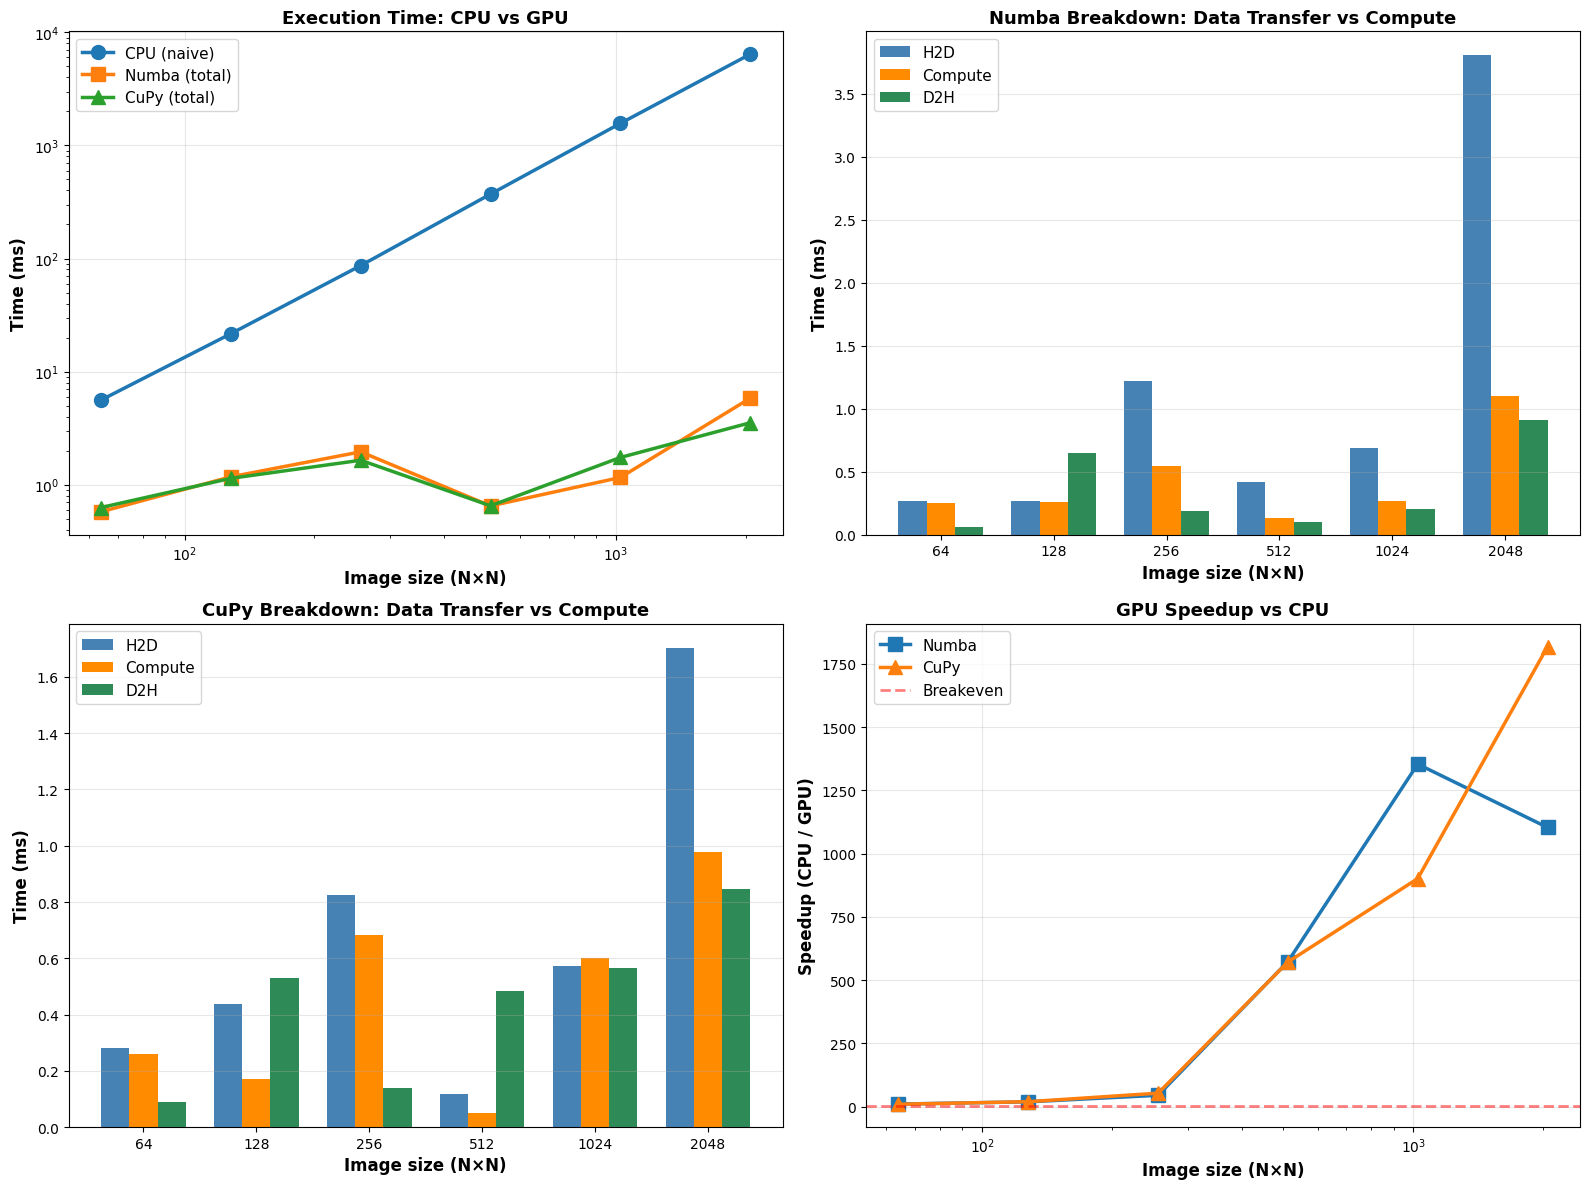

In [13]:
# Soluzione C - Conv3x3 with CuPy, Numba, and CPU
import numpy as np
from numba import cuda
import math, time
import cupyx.scipy.signal as cps
import matplotlib.pyplot as plt
try:
    import cupy as cp
    HAS_CUPY = True
except:
    HAS_CUPY = False
    print("CuPy not available")

# ===== NUMBA CUDA KERNEL =====
@cuda.jit
def conv3x3_kernel(inp, out, k):
    # inp: HxW, out: (H-2)x(W-2), k: 3x3 kernel
    i, j = cuda.grid(2)
    H = inp.shape[0]
    W = inp.shape[1]
    out_H = H - 2
    out_W = W - 2
    if i < out_H and j < out_W:
        s = 0.0
        # apply 3x3 convolution
        for di in range(3):
            for dj in range(3):
                s += k[di, dj] * inp[i+di, j+dj]
        out[i, j] = s

def conv3x3_numba(inp_host, kernel, threads=(16,16)):
    """Numba CUDA implementation with separate timing"""
    H, W = inp_host.shape
    out_H = H - 2
    out_W = W - 2
    
    # H2D transfer
    t0 = time.time()
    inp_d = cuda.to_device(inp_host)
    out_d = cuda.device_array((out_H, out_W), dtype=np.float32)
    k_d = cuda.to_device(kernel)
    cuda.synchronize()
    h2d_time = time.time() - t0
    
    # Compute
    tx, ty = threads
    bx = (out_W + tx - 1) // tx
    by = (out_H + ty - 1) // ty
    
    t0 = time.time()
    conv3x3_kernel[(bx, by), (tx, ty)](inp_d, out_d, k_d)
    cuda.synchronize()
    compute_time = time.time() - t0
    
    # D2H transfer
    t0 = time.time()
    out = out_d.copy_to_host()
    cuda.synchronize()
    d2h_time = time.time() - t0
    
    return out, h2d_time, compute_time, d2h_time

# ===== CPU NAIVE =====
def conv3x3_cpu(inp, kernel):
    """Naive CPU convolution for reference"""
    H, W = inp.shape
    out = np.zeros((H-2, W-2), dtype=np.float32)
    for i in range(H-2):
        for j in range(W-2):
            s = 0.0
            for di in range(3):
                for dj in range(3):
                    s += kernel[di, dj] * inp[i+di, j+dj]
            out[i, j] = s
    return out

# ===== CUPY IMPLEMENTATION =====
def conv3x3_cupy(inp_host, kernel, threads=(16,16)):
    """CuPy implementation using scipy-like convolution"""
    if not HAS_CUPY:
        return None, None, None, None
    
    # H2D transfer
    t0 = time.time()
    inp_d = cp.asarray(inp_host)
    kernel_d = cp.asarray(kernel)
    cp.cuda.Stream.null.synchronize()
    h2d_time = time.time() - t0
    
    # Compute (using correlate2d which is similar to convolution with flipped kernel)
    t0 = time.time()
    out_d = cps.correlate2d(inp_d, kernel_d, mode='valid')
    cp.cuda.Stream.null.synchronize()
    compute_time = time.time() - t0
    
    # D2H transfer
    t0 = time.time()
    out = cp.asnumpy(out_d)
    cp.cuda.Stream.null.synchronize()
    d2h_time = time.time() - t0
    
    return out, h2d_time, compute_time, d2h_time

# ===== TEST WITH MULTIPLE SIZES =====
sizes = [64, 128, 256, 512, 1024, 2048]
results = {
    'cpu': [],
    'numba_h2d': [], 'numba_compute': [], 'numba_d2h': [], 'numba_total': [],
    'cupy_h2d': [], 'cupy_compute': [], 'cupy_d2h': [], 'cupy_total': [],
}
warmup = 20

# Create kernel once (Sobel-like)
k = np.array([[1, 0, -1],
              [1, 0, -1],
              [1, 0, -1]], dtype=np.float32)

print("\n" + "="*100)
print("CONVOLUTION 3×3 - COMPREHENSIVE BENCHMARK")
print("="*100)

for size in sizes:
    H, W = size, size
    img = np.random.rand(H, W).astype(np.float32)
    
    # ===== CPU BASELINE =====
    t0 = time.time()
    out_cpu = conv3x3_cpu(img, k)
    t_cpu = (time.time() - t0) * 1000
    results['cpu'].append(t_cpu)
    
    # ===== NUMBA CUDA =====
    # Warm-up
    _,_,_,_ = conv3x3_numba(img, k, threads=(16,16))

    out_numba, h2d, compute, d2h = conv3x3_numba(img, k, threads=(16,16))
    h2d_ms, compute_ms, d2h_ms = h2d*1000, compute*1000, d2h*1000
    total_ms = h2d_ms + compute_ms + d2h_ms
    results['numba_h2d'].append(h2d_ms)
    results['numba_compute'].append(compute_ms)
    results['numba_d2h'].append(d2h_ms)
    results['numba_total'].append(total_ms)
    
    # ===== CUPY =====
    out_cupy = None
    #Warm-up
    _, _, _, _ = conv3x3_cupy(img, k, threads=(16,16))

    if HAS_CUPY:
        out_cupy, h2d, compute, d2h = conv3x3_cupy(img, k, threads=(16,16))
        h2d_ms, compute_ms, d2h_ms = h2d*1000, compute*1000, d2h*1000
        total_ms = h2d_ms + compute_ms + d2h_ms
        results['cupy_h2d'].append(h2d_ms)
        results['cupy_compute'].append(compute_ms)
        results['cupy_d2h'].append(d2h_ms)
        results['cupy_total'].append(total_ms)
    
    # Correctness checks
    err_numba = np.max(np.abs(out_cpu - out_numba))
    err_cupy = np.max(np.abs(out_cpu - out_cupy)) if HAS_CUPY and out_cupy is not None else float('nan')
    
    print(f"\n{'Size':<8} {size}×{size}")
    print("-" * 100)
    print(f"{'CPU (naive)':<25} {results['cpu'][-1]:>12.2f} ms")
    print(f"  Numba H2D              {results['numba_h2d'][-1]:>12.2f} ms")
    print(f"  Numba Compute          {results['numba_compute'][-1]:>12.2f} ms")
    print(f"  Numba D2H              {results['numba_d2h'][-1]:>12.2f} ms")
    print(f"  {'Numba Total':<21} {results['numba_total'][-1]:>12.2f} ms  (error: {err_numba:.3e})")
    if HAS_CUPY:
        print(f"  CuPy H2D               {results['cupy_h2d'][-1]:>12.2f} ms")
        print(f"  CuPy Compute           {results['cupy_compute'][-1]:>12.2f} ms")
        print(f"  CuPy D2H               {results['cupy_d2h'][-1]:>12.2f} ms")
        print(f"  {'CuPy Total':<21} {results['cupy_total'][-1]:>12.2f} ms  (error: {err_cupy:.3e})")
    
    # Speedups
    speedup_numba = results['cpu'][-1] / results['numba_total'][-1]
    if HAS_CUPY:
        speedup_cupy = results['cpu'][-1] / results['cupy_total'][-1]
        print(f"  Speedups: Numba {speedup_numba:.2f}×  |  CuPy {speedup_cupy:.2f}×")
    else:
        print(f"  Speedup: Numba {speedup_numba:.2f}×")

# ===== PLOTS =====
print("\n" + "="*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Execution time comparison
ax = axes[0, 0]
ax.plot(sizes, results['cpu'], 'o-', label='CPU (naive)', linewidth=2.5, markersize=10)
ax.plot(sizes, results['numba_total'], 's-', label='Numba (total)', linewidth=2.5, markersize=10)
if HAS_CUPY:
    ax.plot(sizes, results['cupy_total'], '^-', label='CuPy (total)', linewidth=2.5, markersize=10)
ax.set_xlabel('Image size (N×N)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
ax.set_title('Execution Time: CPU vs GPU', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Plot 2: Numba breakdown
ax = axes[0, 1]
width = 0.25
x = np.arange(len(sizes))
ax.bar(x - width, results['numba_h2d'], width, label='H2D', color='steelblue')
ax.bar(x, results['numba_compute'], width, label='Compute', color='darkorange')
ax.bar(x + width, results['numba_d2h'], width, label='D2H', color='seagreen')
ax.set_xlabel('Image size (N×N)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
ax.set_title('Numba Breakdown: Data Transfer vs Compute', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}' for s in sizes])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: CuPy breakdown (if available)
if HAS_CUPY:
    ax = axes[1, 0]
    width = 0.25
    x = np.arange(len(sizes))
    ax.bar(x - width, results['cupy_h2d'], width, label='H2D', color='steelblue')
    ax.bar(x, results['cupy_compute'], width, label='Compute', color='darkorange')
    ax.bar(x + width, results['cupy_d2h'], width, label='D2H', color='seagreen')
    ax.set_xlabel('Image size (N×N)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_title('CuPy Breakdown: Data Transfer vs Compute', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}' for s in sizes])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Speedup comparison
ax = axes[1, 1]
speedups_numba = [results['cpu'][i] / results['numba_total'][i] for i in range(len(sizes))]
if HAS_CUPY:
    speedups_cupy = [results['cpu'][i] / results['cupy_total'][i] for i in range(len(sizes))]
    ax.plot(sizes, speedups_numba, 's-', label='Numba', linewidth=2.5, markersize=10)
    ax.plot(sizes, speedups_cupy, '^-', label='CuPy', linewidth=2.5, markersize=10)
else:
    ax.plot(sizes, speedups_numba, 's-', label='Numba', linewidth=2.5, markersize=10, color='darkorange')

ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Breakeven')
ax.set_xlabel('Image size (N×N)', fontsize=12, fontweight='bold')
ax.set_ylabel('Speedup (CPU / GPU)', fontsize=12, fontweight='bold')
ax.set_title('GPU Speedup vs CPU', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()